# Deep Learning Project

# Text Generation using RNN, LSTM and GRU

Objective:
To design and implement deep learning models capable of learning contextual dependencies from text and generating meaningful text sequences using Vanilla RNN, LSTM and GRU architectures.

 **Import Required Libraries**


In [22]:
import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, LSTM, GRU, Dense

from tensorflow.keras.utils import to_categorical

## Load the Text Corpus

For this project, I am using a custom text corpus related to Artificial Intelligence and Machine Learning. The corpus will be used to train the models so that they can learn word relationships and generate meaningful text.

In [23]:
corpus = """
artificial intelligence is transforming the modern world.
machine learning helps computers learn patterns from data.
deep learning is a powerful branch of artificial intelligence.
neural networks are widely used for image and text processing.
students learn programming to build intelligent systems.
recurrent neural networks are useful for sequence prediction.
lstm models capture long term dependencies in text.
gru models are efficient and faster alternatives to lstm.
text generation models predict the next word in a sequence.
deep learning can generate meaningful and coherent sentences.
"""

## Tokenization

Since neural networks cannot directly process text data, the text is converted into numerical form using a tokenizer. Each unique word is assigned a unique integer index.

In [24]:
tokenizer = Tokenizer()
tokenizer.fit_on_texts([corpus])

total_words = len(tokenizer.word_index) + 1

print("Vocabulary Size:", total_words)

print(tokenizer.word_index)

Vocabulary Size: 61
{'learning': 1, 'are': 2, 'and': 3, 'text': 4, 'models': 5, 'artificial': 6, 'intelligence': 7, 'is': 8, 'the': 9, 'learn': 10, 'deep': 11, 'a': 12, 'neural': 13, 'networks': 14, 'for': 15, 'to': 16, 'sequence': 17, 'lstm': 18, 'in': 19, 'transforming': 20, 'modern': 21, 'world': 22, 'machine': 23, 'helps': 24, 'computers': 25, 'patterns': 26, 'from': 27, 'data': 28, 'powerful': 29, 'branch': 30, 'of': 31, 'widely': 32, 'used': 33, 'image': 34, 'processing': 35, 'students': 36, 'programming': 37, 'build': 38, 'intelligent': 39, 'systems': 40, 'recurrent': 41, 'useful': 42, 'prediction': 43, 'capture': 44, 'long': 45, 'term': 46, 'dependencies': 47, 'gru': 48, 'efficient': 49, 'faster': 50, 'alternatives': 51, 'generation': 52, 'predict': 53, 'next': 54, 'word': 55, 'can': 56, 'generate': 57, 'meaningful': 58, 'coherent': 59, 'sentences': 60}


## Create Input Sequences

The text is converted into n-gram sequences. These sequences help the model learn how words appear together in a sentence and predict the next word based on previous words.

In [25]:
input_sequences = []

for line in corpus.split('\n'):

    token_list = tokenizer.texts_to_sequences([line])[0]

    for i in range(1, len(token_list)):
        n_gram_sequence = token_list[:i+1]
        input_sequences.append(n_gram_sequence)

max_len = max(len(seq) for seq in input_sequences)

input_sequences = pad_sequences(
    input_sequences,
    maxlen=max_len,
    padding='pre'
)

print("Total Sequences:", len(input_sequences))
print("Max Length:", max_len)

Total Sequences: 74
Max Length: 10


 ## Prepare Input Features and Target Labels

The last word of every sequence becomes the target output (y), and the remaining words become the input (X).

In [26]:
X = input_sequences[:, :-1]
y = input_sequences[:, -1]

y = to_categorical(y, num_classes=total_words)

print(X.shape)
print(y.shape)

(74, 9)
(74, 61)


## Vanilla RNN Model

A Vanilla Recurrent Neural Network is implemented as the first model. It processes the text sequentially and learns dependencies between words. This model serves as the baseline for comparison.

In [27]:
rnn_model = Sequential([
    Embedding(total_words, 128, input_length=max_len-1),
    SimpleRNN(128),
    Dense(total_words, activation='softmax')
])

rnn_model.compile(
    loss='categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

rnn_model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_3 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_1 (SimpleRNN)        │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

## Train the Vanilla RNN Model

The model is trained for 200 epochs.

During training, the network learns to predict the next word in a sequence based on the previous words

In [28]:
rnn_history = rnn_model.fit(
    X,
    y,
    epochs=200,
    verbose=1
)

Epoch 1/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step - accuracy: 0.0135 - loss: 4.1299
Epoch 2/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.1757 - loss: 3.9971
Epoch 3/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.2568 - loss: 3.9073
Epoch 4/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.2838 - loss: 3.8083
Epoch 5/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.3108 - loss: 3.7140
Epoch 6/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.3108 - loss: 3.6187
Epoch 7/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.3243 - loss: 3.5075
Epoch 8/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.3784 - loss: 3.3947
Epoch 9/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.4054 - loss: 3.2703
Epoch 10/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.4730 - loss: 3.1367
Epoch 11/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.5270 - loss: 2.9882
Epoch 12/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.5811 - lo

## Plot the Training Loss of Vanilla RNN

The following graph shows how the loss decreases as the number of training epochs increases.

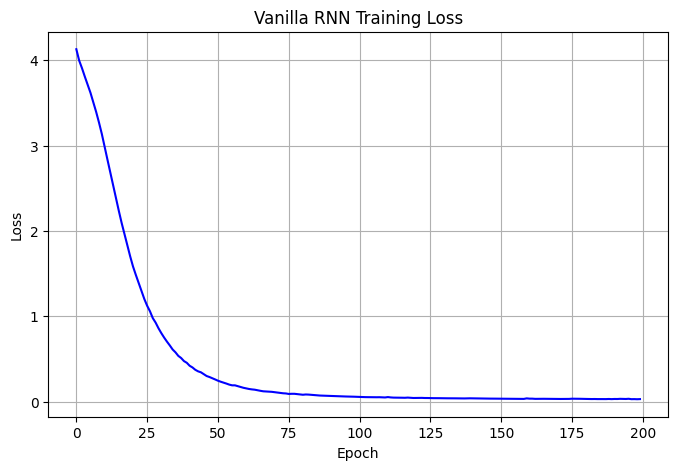

In [29]:
plt.figure(figsize=(8,5))

plt.plot(rnn_history.history['loss'], color='blue')

plt.title("Vanilla RNN Training Loss")

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.grid(True)

plt.show()

## Observation

The loss should gradually decrease as training progresses. Since this is a simple recurrent neural network, it learns basic sentence patterns, but it may not perform well on long-term dependencies.

## LSTM Model

Long Short-Term Memory (LSTM) networks are designed to overcome the short-memory limitation of traditional RNNs. They are capable of capturing long-term dependencies present in text sequences.

In [30]:
lstm_model = Sequential([
    Embedding(total_words, 128, input_length=max_len-1),
    LSTM(128),
    Dense(total_words, activation='softmax')
])

lstm_model.compile(
    loss='categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

lstm_model.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_4 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

## Train the LSTM Model

The model is trained for 200 epochs using the prepared training dataset.

In [31]:
lstm_history = lstm_model.fit(
    X,
    y,
    epochs=200,
    verbose=1
)

Epoch 1/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 26ms/step - accuracy: 0.0000e+00 - loss: 4.1141
Epoch 2/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.1351 - loss: 4.0981
Epoch 3/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.2297 - loss: 4.0851
Epoch 4/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 0.1486 - loss: 4.0690
Epoch 5/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.0946 - loss: 4.0490
Epoch 6/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.0946 - loss: 4.0198
Epoch 7/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.0676 - loss: 3.9811
Epoch 8/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.0541 - loss: 3.9067
Epoch 9/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.0946 - loss: 3.8413
Epoch 10/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.0676 - loss: 3.8495
Epoch 11/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - accuracy: 0.0676 - loss: 3.7996
Epoch 12/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - accuracy: 0.1081 

## GRU Model

Gated Recurrent Unit (GRU) is a simplified version of LSTM. It uses fewer parameters while still effectively learning long-term relationships in sequential data.

In [32]:
gru_model = Sequential([
    Embedding(total_words, 128, input_length=max_len-1),
    GRU(128),
    Dense(total_words, activation='softmax')
])

gru_model.compile(
    loss='categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

gru_model.summary()

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_5 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_1 (GRU)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [33]:
gru_history = gru_model.fit(
    X,
    y,
    epochs=200,
    verbose=1
)

Epoch 1/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 22ms/step - accuracy: 0.0000e+00 - loss: 4.1129
Epoch 2/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.1486 - loss: 4.0885
Epoch 3/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.2838 - loss: 4.0672
Epoch 4/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 0.3108 - loss: 4.0448
Epoch 5/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.2703 - loss: 4.0183
Epoch 6/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - accuracy: 0.2297 - loss: 3.9834
Epoch 7/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - accuracy: 0.1622 - loss: 3.9415
Epoch 8/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - accuracy: 0.1216 - loss: 3.8773
Epoch 9/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - accuracy: 0.1216 - loss: 3.7795
Epoch 10/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - accuracy: 0.1081 - loss: 3.7288 
Epoch 11/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - accuracy: 0.1486 - loss: 3.6874
Epoch 12/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - accuracy: 0.1486

In [34]:
print("Final Training Loss :", gru_history.history['loss'][-1])

print("Final Training Accuracy :", gru_history.history['accuracy'][-1])

Final Training Loss : 0.03242034465074539
Final Training Accuracy : 0.9864864945411682


## Training Loss Comparison
The following graph compares the loss reduction of Vanilla RNN, LSTM and GRU models over 200 training epochs.

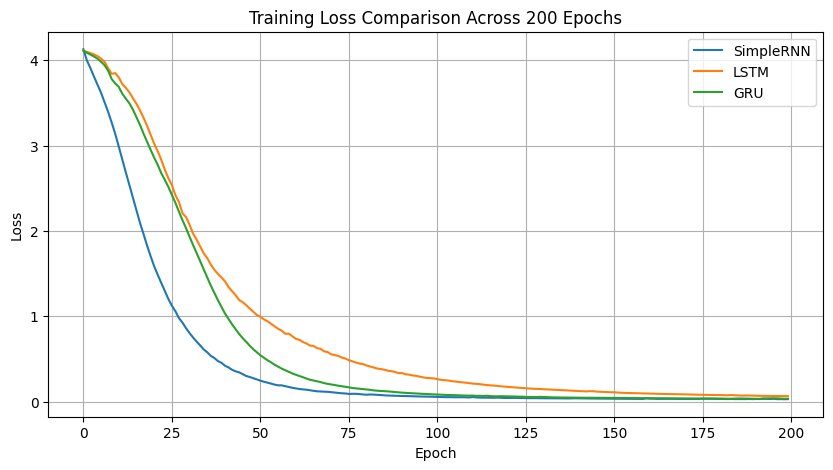

In [35]:
plt.figure(figsize=(10,5))

plt.plot(
    rnn_history.history['loss'],
    label='SimpleRNN'
)

plt.plot(
    lstm_history.history['loss'],
    label='LSTM'
)

plt.plot(
    gru_history.history['loss'],
    label='GRU'
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss Comparison Across 200 Epochs")
plt.legend()
plt.grid(True)

plt.show()

## Text Generation Function

This function predicts one word at a time using the trained model. The predicted word is added to the input sentence, and the process is repeated until the required number of words is generated.

In [36]:
def generate_text(model, seed_text, next_words=10):

    for _ in range(next_words):

        token_list = tokenizer.texts_to_sequences(
            [seed_text]
        )[0]

        token_list = pad_sequences(
            [token_list],
            maxlen=max_len-1,
            padding='pre'
        )

        predicted_probs = model.predict(
            token_list,
            verbose=0
        )

        predicted_index = np.argmax(predicted_probs)

        output_word = ""

        for word, index in tokenizer.word_index.items():
            if index == predicted_index:
                output_word = word
                break

        seed_text += " " + output_word

    return seed_text

# 1. Generate Text using Vanilla RNN
# 2. Generate Text using LSTM
# 3. Generate Text using GRU

In [37]:
print(generate_text(rnn_model, "deep learning", 10))

deep learning can generate meaningful and coherent sentences in a sequence prediction


In [38]:
print(generate_text(lstm_model, "deep learning", 10))

deep learning can generate meaningful and coherent sentences sentences sentences lstm processing


In [39]:
print(generate_text(gru_model, "deep learning", 10))

deep learning is a powerful branch of artificial intelligence is transforming the


## Compare Final Loss Values

In [40]:
print("Vanilla RNN Loss :", rnn_history.history['loss'][-1])

print("LSTM Loss :", lstm_history.history['loss'][-1])

print("GRU Loss :", gru_history.history['loss'][-1])

Vanilla RNN Loss : 0.028421830385923386
LSTM Loss : 0.06328370422124863
GRU Loss : 0.03242034465074539


# Conclusion

In this project, text generation was performed using Vanilla RNN, LSTM, and GRU architectures. All models successfully learned patterns from the training corpus and generated text sequences. LSTM and GRU generally produced more coherent outputs due to their ability to capture long-term dependencies. The comparison of training losses helped evaluate the learning performance of each model.